In [1]:
import os

print("="*80)
print("KAGGLE INPUT")
print("="*80)

for root, dirs, files in os.walk("/kaggle/input"):
    print(root)
    for f in files[:5]:
        print("   ", f)

KAGGLE INPUT
/kaggle/input
/kaggle/input/models
/kaggle/input/models/swastikprakash
/kaggle/input/models/swastikprakash/con
/kaggle/input/models/swastikprakash/con/pytorch
/kaggle/input/models/swastikprakash/con/pytorch/default
/kaggle/input/models/swastikprakash/con/pytorch/default/1
    best_convnext_baseline.pth
/kaggle/input/datasets
/kaggle/input/datasets/organizations
/kaggle/input/datasets/organizations/nih-chest-xrays
/kaggle/input/datasets/organizations/nih-chest-xrays/data
    LOG_CHESTXRAY.pdf
    README_CHESTXRAY.pdf
    BBox_List_2017.csv
    test_list.txt
    ARXIV_V5_CHESTXRAY.pdf
/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_003
/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_003/images
    00006199_010.png
    00004833_016.png
    00006260_000.png
    00004911_010.png
    00004186_007.png
/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_012
/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_012/images
  

In [2]:
import os
import cv2
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    classification_report,
    multilabel_confusion_matrix,
    roc_auc_score
)

warnings.filterwarnings("ignore")

In [3]:
SEED = 42

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

IMAGE_SIZE = 224

BATCH_SIZE = 32

NUM_WORKERS = 2

NUM_CLASSES = 14

MODEL_PATH = "/kaggle/input/models/swastikprakash/con/pytorch/default/1/best_convnext_baseline.pth"

DATASET_PATH = "/kaggle/input/datasets/organizations/nih-chest-xrays/data"

print("Device :", DEVICE)
print("Model :", MODEL_PATH)

Device : cuda
Model : /kaggle/input/models/swastikprakash/con/pytorch/default/1/best_convnext_baseline.pth


In [4]:
DISEASES = [

"Atelectasis",
"Cardiomegaly",
"Consolidation",
"Edema",
"Effusion",
"Emphysema",
"Fibrosis",
"Hernia",
"Infiltration",
"Mass",
"Nodule",
"Pleural_Thickening",
"Pneumonia",
"Pneumothorax"

]

In [5]:
metadata = pd.read_csv(

    os.path.join(
        DATASET_PATH,
        "Data_Entry_2017.csv"
    )

)

metadata = metadata.drop(
    columns=["Unnamed: 11"],
    errors="ignore"
)

print(metadata.shape)

metadata.head()

(112120, 11)


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y]
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143


In [6]:
IMAGE_PATH_DICT = {}

for root, dirs, files in os.walk(DATASET_PATH):

    for file in files:

        if file.endswith(".png"):

            IMAGE_PATH_DICT[file] = os.path.join(root,file)

metadata["Image Path"] = metadata["Image Index"].map(
    IMAGE_PATH_DICT
)

metadata = metadata.dropna().reset_index(drop=True)

print(len(metadata))

112120


In [7]:
for disease in DISEASES:

    metadata[disease] = metadata["Finding Labels"].apply(

        lambda x: int(disease in x.split("|"))

    )

metadata.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,...,Effusion,Emphysema,Fibrosis,Hernia,Infiltration,Mass,Nodule,Pleural_Thickening,Pneumonia,Pneumothorax
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,...,0,0,0,0,0,0,0,0,0,0
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,...,0,1,0,0,0,0,0,0,0,0
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,...,1,0,0,0,0,0,0,0,0,0
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,...,0,0,0,0,0,0,0,0,0,0
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,...,0,0,0,1,0,0,0,0,0,0


In [8]:
gss = GroupShuffleSplit(
    n_splits=1,
    train_size=0.70,
    random_state=SEED
)

train_idx, temp_idx = next(

    gss.split(
        metadata,
        groups=metadata["Patient ID"]
    )

)

train_df = metadata.iloc[train_idx]

temp_df = metadata.iloc[temp_idx]

gss2 = GroupShuffleSplit(

    n_splits=1,

    train_size=2/3,

    random_state=SEED

)

val_idx, test_idx = next(

    gss2.split(

        temp_df,

        groups=temp_df["Patient ID"]

    )

)

test_df = temp_df.iloc[test_idx].reset_index(drop=True)

print(len(test_df))

11350


In [9]:
def apply_clahe(img):

    clahe = cv2.createCLAHE(

        clipLimit=2,

        tileGridSize=(8,8)

    )

    return clahe.apply(img)

In [10]:
transform = transforms.Compose([

    transforms.ToPILImage(),

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(

        mean=[0.485,0.456,0.406],

        std=[0.229,0.224,0.225]

    )

])

In [11]:
# ============================================================
# Cell 10 : Dataset
# ============================================================

class NIHChestDataset(Dataset):

    def __init__(self, dataframe):

        self.df = dataframe

    def __len__(self):

        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        image = cv2.imread(
            row["Image Path"],
            cv2.IMREAD_GRAYSCALE
        )

        image = apply_clahe(image)

        image = cv2.cvtColor(
            image,
            cv2.COLOR_GRAY2RGB
        )

        image = transform(image)

        label = row[DISEASES].values.astype(np.float32)

        return image, torch.tensor(label)

In [12]:
# ============================================================
# Cell 11 : Test Loader
# ============================================================

test_dataset = NIHChestDataset(test_df)

test_loader = DataLoader(

    test_dataset,

    batch_size=32,

    shuffle=False,

    num_workers=2,

    pin_memory=True

)

print("Test Images :", len(test_dataset))
print("Test Batches:", len(test_loader))

Test Images : 11350
Test Batches: 355


In [13]:
# ============================================================
# Cell 12 : ConvNeXt
# ============================================================

weights = ConvNeXt_Tiny_Weights.DEFAULT

model = convnext_tiny(weights=weights)

in_features = model.classifier[2].in_features

model.classifier[2] = nn.Linear(
    in_features,
    NUM_CLASSES
)

model = model.to(DEVICE)

print("Model Ready")

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 221MB/s] 


Model Ready


In [14]:
# ============================================================
# Cell 13 : Load Model
# ============================================================

checkpoint = torch.load(

    MODEL_PATH,

    map_location=DEVICE,

    weights_only=False

)

print(checkpoint.keys())

dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'scheduler_state_dict', 'best_auc', 'history'])


In [15]:
# ============================================================
# Cell 14 : Load Trained Weights
# ============================================================

model.load_state_dict(checkpoint["model_state_dict"])

model.eval()

history = checkpoint["history"]

print("="*60)
print("✅ Model Loaded Successfully")
print(f"Best Validation AUROC : {checkpoint['best_auc']:.4f}")
print(f"Best Epoch            : {checkpoint['epoch']}")
print("="*60)

✅ Model Loaded Successfully
Best Validation AUROC : 0.8371
Best Epoch            : 6


In [18]:
from tqdm.auto import tqdm

In [19]:
# ============================================================
# Cell 15 : Test Inference
# ============================================================

all_labels = []
all_predictions = []
all_probabilities = []

model.eval()

with torch.no_grad():

    for images, labels in tqdm(test_loader):

        images = images.to(DEVICE)

        outputs = model(images)

        probs = torch.sigmoid(outputs)

        preds = (probs >= 0.5).float()

        all_labels.append(labels.numpy())
        all_predictions.append(preds.cpu().numpy())
        all_probabilities.append(probs.cpu().numpy())

all_labels = np.concatenate(all_labels)
all_predictions = np.concatenate(all_predictions)
all_probabilities = np.concatenate(all_probabilities)

print("Inference Completed")

print(all_labels.shape)
print(all_predictions.shape)

  0%|          | 0/355 [00:00<?, ?it/s]

libpng warning: iCCP: profile 'ICC Profile': 'GRAY': Gray color space not permitted on RGB PNG
libpng warning: iCCP: profile 'ICC Profile': 'GRAY': Gray color space not permitted on RGB PNG


Inference Completed
(11350, 14)
(11350, 14)


In [20]:
# ============================================================
# Cell 16 : Classification Report
# ============================================================

from sklearn.metrics import classification_report

report = classification_report(
    all_labels,
    all_predictions,
    target_names=DISEASES,
    zero_division=0,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

print(report_df)

report_df.to_csv(
    "/kaggle/working/classification_report.csv",
    index=True
)

print("\nClassification report saved successfully.")

                    precision    recall  f1-score  support
Atelectasis          0.251149  0.656652  0.363334   1165.0
Cardiomegaly         0.205151  0.702128  0.317526    329.0
Consolidation        0.105031  0.726087  0.183516    460.0
Edema                0.098676  0.788462  0.175401    208.0
Effusion             0.334465  0.782367  0.468601   1259.0
Emphysema            0.154362  0.823881  0.260009    335.0
Fibrosis             0.049417  0.588889  0.091183    180.0
Hernia               0.144737  0.440000  0.217822     25.0
Infiltration         0.309351  0.564063  0.399566   1959.0
Mass                 0.165414  0.684825  0.266465    514.0
Nodule               0.107841  0.715200  0.187421    625.0
Pleural_Thickening   0.087020  0.702065  0.154847    339.0
Pneumonia            0.040364  0.533835  0.075053    133.0
Pneumothorax         0.216786  0.811765  0.342189    595.0
micro avg            0.171139  0.685208  0.273874   8126.0
macro avg            0.162126  0.680016  0.250210   8126

In [21]:
# ============================================================
# Cell 17 : Overall Metrics
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)

print("="*60)

print("Macro Precision :", precision_score(
    all_labels,
    all_predictions,
    average="macro",
    zero_division=0
))

print("Macro Recall :", recall_score(
    all_labels,
    all_predictions,
    average="macro",
    zero_division=0
))

print("Macro F1 :", f1_score(
    all_labels,
    all_predictions,
    average="macro",
    zero_division=0
))

print("Macro AUROC :", roc_auc_score(
    all_labels,
    all_probabilities,
    average="macro"
))

print("="*60)

Macro Precision : 0.1621260418504502
Macro Recall : 0.6800155248791366
Macro F1 : 0.2502095832985552
Macro AUROC : 0.8325189819815365


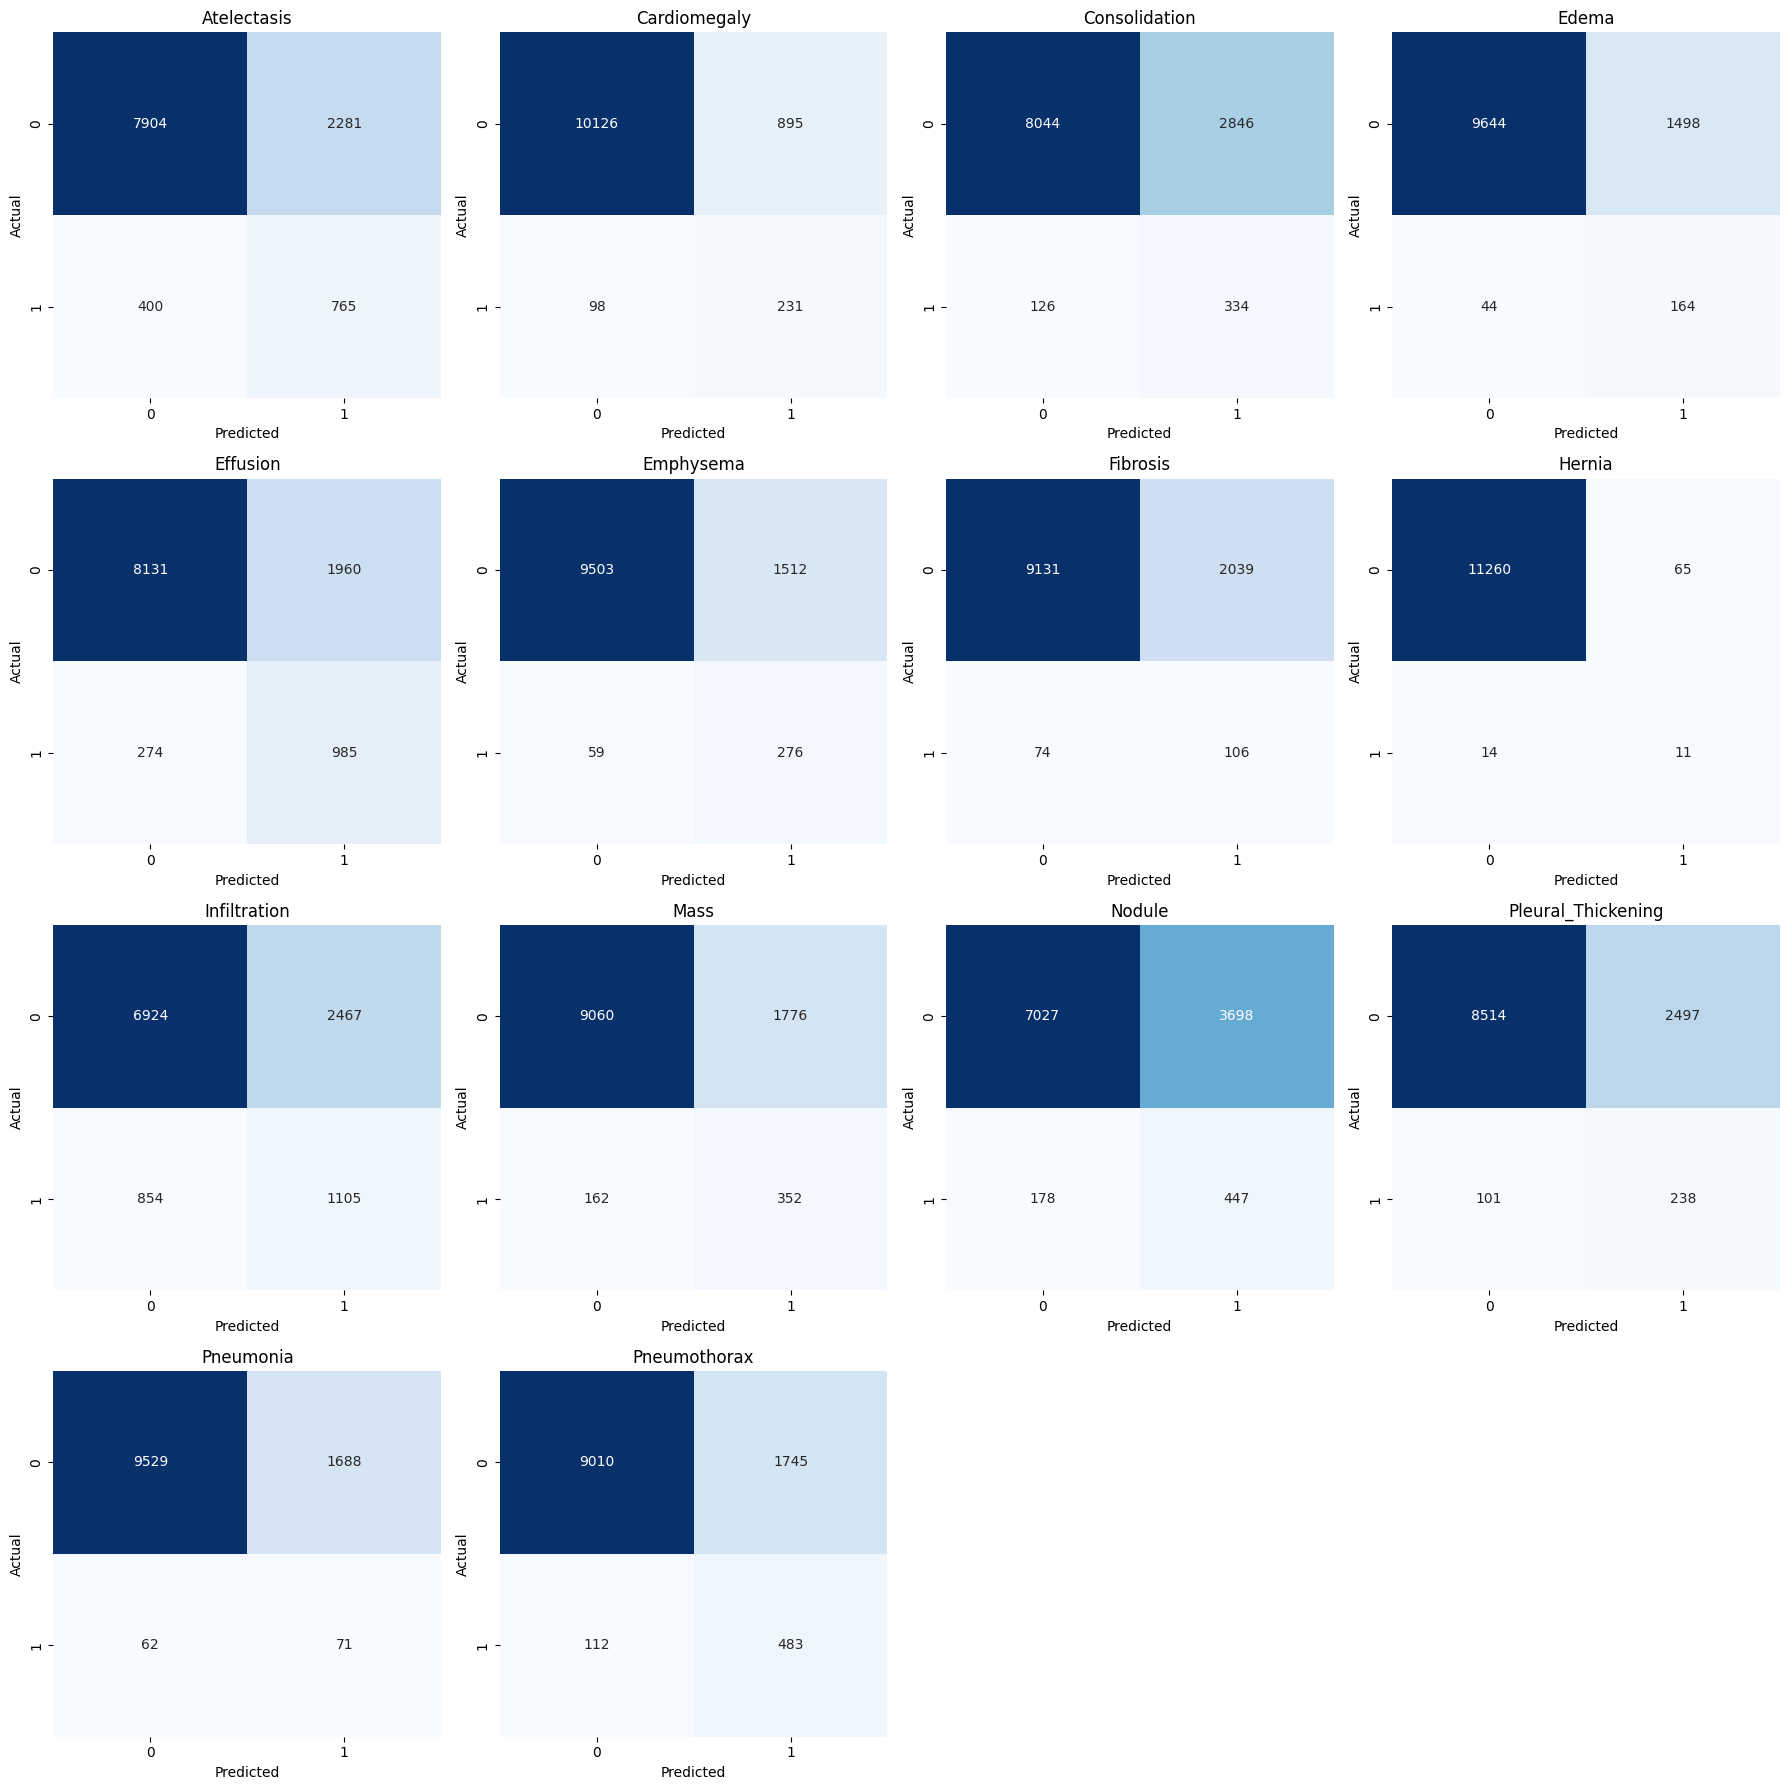

In [22]:
# ============================================================
# Cell 18 : Confusion Matrices
# ============================================================

from sklearn.metrics import multilabel_confusion_matrix
import seaborn as sns

cms = multilabel_confusion_matrix(
    all_labels,
    all_predictions
)

fig, axes = plt.subplots(4,4, figsize=(18,18))

axes = axes.flatten()

for i in range(NUM_CLASSES):

    sns.heatmap(

        cms[i],

        annot=True,

        fmt="d",

        cmap="Blues",

        cbar=False,

        ax=axes[i]

    )

    axes[i].set_title(DISEASES[i])

    axes[i].set_xlabel("Predicted")

    axes[i].set_ylabel("Actual")

for j in range(NUM_CLASSES,16):

    axes[j].axis("off")

plt.tight_layout()

plt.show()

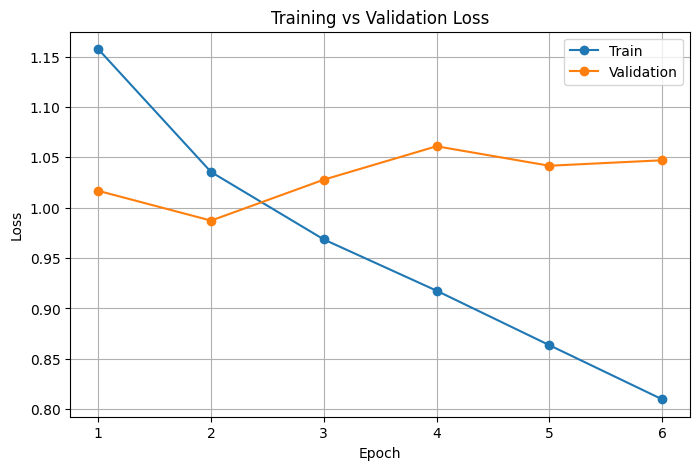

In [23]:
# ============================================================
# Cell 19 : Loss Curve
# ============================================================

epochs = range(
    1,
    len(history["train_loss"])+1
)

plt.figure(figsize=(8,5))

plt.plot(

    epochs,

    history["train_loss"],

    marker="o",

    label="Train"

)

plt.plot(

    epochs,

    history["val_loss"],

    marker="o",

    label="Validation"

)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.grid(True)

plt.legend()

plt.show()

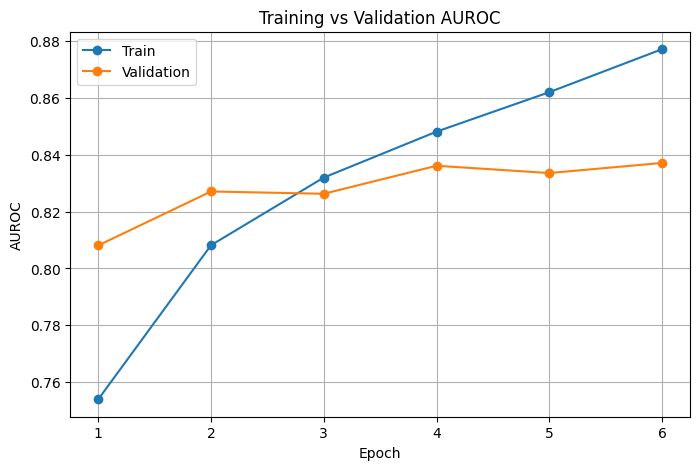

In [24]:
# ============================================================
# Cell 20 : AUROC Curve
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(

    epochs,

    history["train_auc"],

    marker="o",

    label="Train"

)

plt.plot(

    epochs,

    history["val_auc"],

    marker="o",

    label="Validation"

)

plt.xlabel("Epoch")

plt.ylabel("AUROC")

plt.title("Training vs Validation AUROC")

plt.grid(True)

plt.legend()

plt.show()

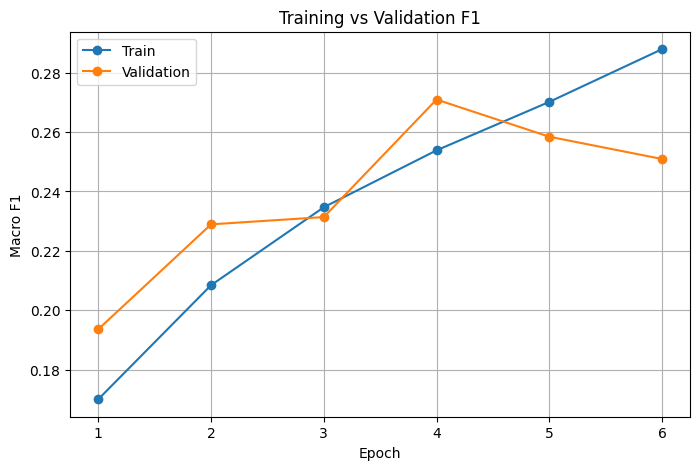

In [25]:
# ============================================================
# Cell 21 : F1 Curve
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(

    epochs,

    history["train_f1"],

    marker="o",

    label="Train"

)

plt.plot(

    epochs,

    history["val_f1"],

    marker="o",

    label="Validation"

)

plt.xlabel("Epoch")

plt.ylabel("Macro F1")

plt.title("Training vs Validation F1")

plt.grid(True)

plt.legend()

plt.show()

               Disease     AUROC
0          Atelectasis  0.796422
1         Cardiomegaly  0.904407
2        Consolidation  0.793634
3                Edema  0.909128
4             Effusion  0.871957
5            Emphysema  0.924269
6             Fibrosis  0.793337
7               Hernia  0.877807
8         Infiltration  0.706543
9                 Mass  0.845470
10              Nodule  0.761488
11  Pleural_Thickening  0.808956
12           Pneumonia  0.777071
13        Pneumothorax  0.884779


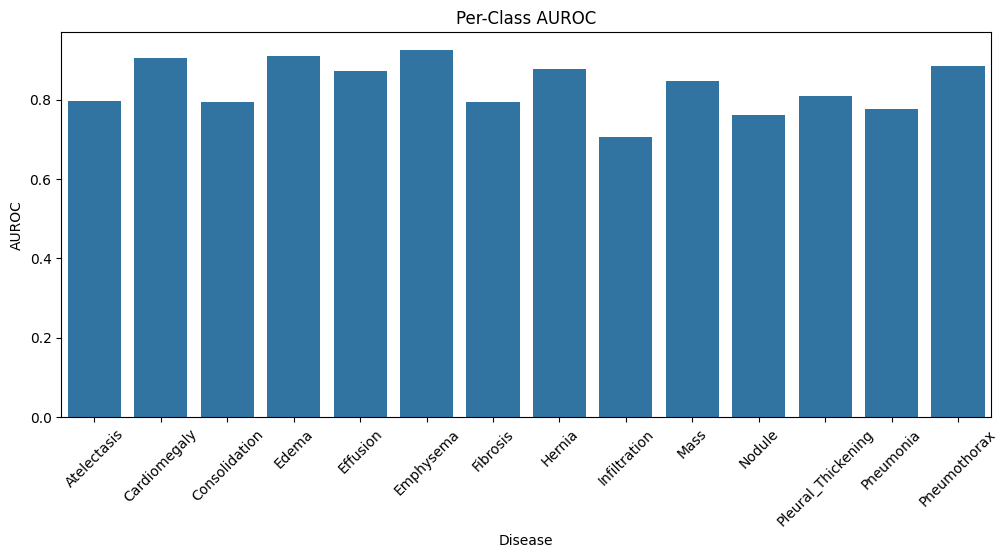

In [26]:
# ============================================================
# Cell 22 : Per-Class AUROC
# ============================================================

aurocs = []

for i in range(NUM_CLASSES):

    try:

        score = roc_auc_score(

            all_labels[:,i],

            all_probabilities[:,i]

        )

    except:

        score = np.nan

    aurocs.append(score)

auroc_df = pd.DataFrame({

    "Disease":DISEASES,

    "AUROC":aurocs

})

print(auroc_df)

plt.figure(figsize=(12,5))

sns.barplot(

    data=auroc_df,

    x="Disease",

    y="AUROC"

)

plt.xticks(rotation=45)

plt.title("Per-Class AUROC")

plt.show()

In [27]:
# ============================================================
# Cell 23 : Save Outputs
# ============================================================

np.save(
    "/kaggle/working/test_predictions.npy",
    all_predictions
)

np.save(
    "/kaggle/working/test_probabilities.npy",
    all_probabilities
)

pd.DataFrame(history).to_csv(
    "/kaggle/working/training_history.csv",
    index=False
)

print("="*60)
print("Everything Saved Successfully!")
print("="*60)

Everything Saved Successfully!
